# ANÁLISE EXPLORATÓRIA DE DADOS (EDA)
### Antes de modelar — confirmar com números reais as hipóteses da Gold

Este notebook cobre os Conteúdos Mínimos 2.1, 2.2 e 2.3 do Estudo Guiado, lendo
direto da camada **Silver**. Ele não grava tabela nova — o objetivo é gerar os
gráficos/estatísticas que embasam o relatório final e validar decisões em aberto
que ficaram pendentes no planejamento da Gold.

**Versão com novas seções adicionadas** —  Mudanças:
- Investigação do pico de volume/alertas no fim de junho (seção 2.1.4, NOVA)
- Histograma de tempo entre alertas consecutivos, pra validar a janela de 4h (seção 2.2.4, NOVA)
- Checagem de redundância entre o sufixo "- active/- inactive" do `alarme` e a coluna `classe` (seção 2.3.4, NOVA)
- Conclusão sobre o mapeamento `telemetria` × `regras`: já foi testado e **rejeitado** — taxonomias diferentes, não é a mesma escala. Mantido só como registro do teste, não mais como validação pendente.

## 0. Setup
Carregar todos os datasets disponíveis e apresentar

In [0]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_style("whitegrid")

df_apontamentos = spark.table("`estudo-guiado`.vale_silver.apontamentos")
df_telemetria    = spark.table("`estudo-guiado`.vale_silver.telemetria")
df_regras        = spark.table("`estudo-guiado`.vale_silver.alarmes_regras")

## CM 2.1 — Carregamento e Inspeção Inicial

### 2.1.1 Shape, tipos e nulos (visão consolidada)
shape (linhas × colunas), tipos de dados (dtypes), 
contagem de valores nulos por coluna e quantidade de registros duplicados. 

In [0]:
def resumo_schema(df, nome):
    linhas = []
    total = df.count()
    for coluna, tipo in df.dtypes:
        qtd_nulos = df.filter(F.col(coluna).isNull()).count()
        linhas.append({
            "Tabela": nome,
            "Coluna": coluna,
            "Tipo": tipo,
            "Pct_Nulos": round(100 * qtd_nulos / total, 2),
        })
    return pd.DataFrame(linhas)

resumo_apontamentos = resumo_schema(df_apontamentos, "apontamentos")
resumo_telemetria = resumo_schema(df_telemetria, "telemetria")

print(f"Apontamentos: {df_apontamentos.count():,} linhas x {len(df_apontamentos.columns)} colunas")
print(f"Telemetria:   {df_telemetria.count():,} linhas x {len(df_telemetria.columns)} colunas")
display(pd.concat([resumo_apontamentos, resumo_telemetria]))

Apontamentos: 377,907 linhas x 10 colunas
Telemetria:   37,164,054 linhas x 19 colunas


Tabela,Coluna,Tipo,Pct_Nulos
apontamentos,Id,bigint,0.0
apontamentos,Inicio,timestamp,0.0
apontamentos,Fim,timestamp,0.0
apontamentos,Tag,string,0.0
apontamentos,Frota,string,0.0
apontamentos,Tipo,string,0.0
apontamentos,Classe,string,0.0
apontamentos,duracao_minutos,double,0.0
apontamentos,flag_overlap_ciclo,boolean,0.0
apontamentos,flag_outlier_duracao,boolean,0.0


### 2.1.2 Distribuição temporal — janela de datas e volume por dia
identificar a janela de datas cobertas pelos dados, frequência média de 
registros por dia/hora e equipamento. 

Período coberto pela Telemetria: 2025-01-01 00:00:00.017000 até 2025-06-30 23:59:56.887000


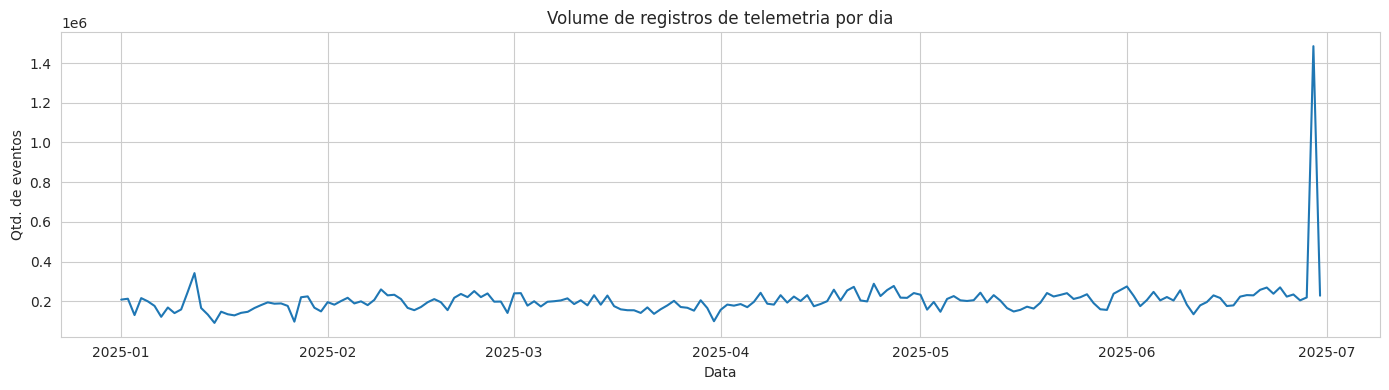

In [0]:
periodo = df_telemetria.select(
    F.min("data_evento").alias("data_min"), F.max("data_evento").alias("data_max")
).collect()[0]
print(f"Período coberto pela Telemetria: {periodo['data_min']} até {periodo['data_max']}")

df_volume_dia = (
    df_telemetria
    .withColumn("data", F.to_date("data_evento"))
    .groupBy("data")
    .count()
    .orderBy("data")
)
pdf_volume_dia = df_volume_dia.toPandas()

plt.figure(figsize=(14, 4))
plt.plot(pdf_volume_dia["data"], pdf_volume_dia["count"])
plt.title("Volume de registros de telemetria por dia")
plt.xlabel("Data")
plt.ylabel("Qtd. de eventos")
plt.tight_layout()
plt.show()

# RESULTADO OBTIDO: pico de ~1,5M de eventos no fim de junho/2025, contra uma faixa
# normal de 150-300k/dia no resto do período. Investigado na seção 2.1.4 abaixo.

### 2.1.3 Estatísticas descritivas das variáveis numéricas
tabela com min, max, média, mediana e desvio padrão para todas as variáveis 
numéricas. 

In [0]:
display(df_telemetria.select("valor").describe())

if "qtd" in df_regras.columns:
    display(df_regras.select("qtd", "tempo").describe())

summary,valor
count,36926611
mean,4.569502824555195
stddev,28.503366266368253
min,0.0
max,4347.0


summary,qtd,tempo
count,151,151
mean,2.410596026490066,221.72185430463577
stddev,2.2159167348340127,290.5713029863844
min,1,0
max,10,720


### 2.1.4 NOVO — Investigação do pico de volume no fim de junho
O gráfico da seção 2.1.2 mostrou um pico isolado muito acima do padrão. Antes de seguir, precisamos saber: é um problema de ingestão (reprocessamento, sensor travado repetindo o mesmo evento) ou um evento operacional real (ex: parada geral de frota, manutenção em massa)? A resposta muda completamente como tratamos esse dia — descartar como outlier de ingestão vs. manter como sinal real de negócio.

In [0]:
# 1) Identifica o dia exato do pico de volume
dia_pico_volume = df_volume_dia.orderBy(F.desc("count")).limit(1).collect()[0]
print(f"Dia de pico de volume: {dia_pico_volume['data']} com {dia_pico_volume['count']:,} eventos")

# 2) O pico de volume coincide com o pico de alertas Don't Go?
df_alertas_por_dia_check = (
    df_telemetria.filter(F.col("is_dont_go") == 1)
    .withColumn("data", F.to_date("data_evento"))
    .groupBy("data").count().orderBy(F.desc("count"))
)
dia_pico_alertas = df_alertas_por_dia_check.limit(1).collect()[0]
print(f"Dia de pico de alertas: {dia_pico_alertas['data']} com {dia_pico_alertas['count']:,} alertas")

coincide = dia_pico_volume["data"] == dia_pico_alertas["data"]
print(f"\nOs dois picos são o mesmo dia? {'SIM' if coincide else 'NÃO'}")

Dia de pico de volume: 2025-06-29 com 1,484,732 eventos
Dia de pico de alertas: 2025-06-30 com 1,123 alertas

Os dois picos são o mesmo dia? NÃO


In [0]:
# 3) HIPÓTESE A TESTAR: será que o equipamento com mais alertas no total do período
#    (o "CA65926", que só vamos confirmar formalmente mais adiante, na seção 2.2.2)
#    também é o responsável pelo PICO DE VOLUME deste dia específico? Testamos aqui
#    porque, se a resposta for sim, o pico de volume e o alto número de alertas do
#    CA65926 teriam a mesma causa raiz — o que mudaria a decisão de tratamento dos dois
#    problemas ao mesmo tempo. Se a resposta for não (como veremos), são dois problemas
#    de origens diferentes, e cada um precisa de um tratamento próprio.
df_pico_por_tag = (
    df_telemetria
    .filter(F.to_date("data_evento") == F.lit(dia_pico_volume["data"]))
    .groupBy("tag")
    .count()
    .orderBy(F.desc("count"))
    .limit(10)
    .toPandas()
)
print(f"Top 10 equipamentos por volume de eventos no dia do pico ({dia_pico_volume['data']}):")
display(df_pico_por_tag)

# 4) Zoom no CA65926: quantos eventos e quantos são o MESMO alarme repetido?
df_ca65926_no_pico = (
    df_telemetria
    .filter((F.col("tag") == "CA65926") & (F.to_date("data_evento") == F.lit(dia_pico_volume["data"])))
    .groupBy("alarme", "is_dont_go")
    .count()
    .orderBy(F.desc("count"))
    .limit(15)
    .toPandas()
)
print("\nDistribuição de alarme no CA65926 durante o dia do pico "
      "(muitas repetições do MESMO alarme = indício de sensor travado/reingestão):")
display(df_ca65926_no_pico)

Top 10 equipamentos por volume de eventos no dia do pico (2025-06-29):


tag,count
PE3798,1334065
PE3797,58495
PE3799,49766
PE3795,26926
CA65930,1591
CA65909,1407
CA65935,1280
CA65932,1120
CA65915,1063
CA65931,875



Distribuição de alarme no CA65926 durante o dia do pico (muitas repetições do MESMO alarme = indício de sensor travado/reingestão):


alarme,is_dont_go,count
right front brake temperature - inactive,0,94
right front brake temperature - active,1,93
dipper,0,37
cycle,0,7
load,0,7
body up,0,7
oem interface timeout,0,6
oem interface normal,0,5
differential filter switch - inactive,0,3
differential filter switch - active,0,3


**Decisão a registrar no Controle de Alterações, depois de rodar as células acima:**
- Se um único `alarme` concentrar a maior parte dos eventos do CA65926 naquele dia 
  forte indício de repetição técnica (ruído de ingestão), não comportamento real do
  equipamento. Considerar tratar como outlier na Gold (ex: cap no número de eventos
  por tag/hora, ou excluir esse dia da agregação com justificativa registrada).
- Se os eventos forem diversos (vários alarmes diferentes, não repetição do mesmo) 
  pode ser uma parada geral de frota real, e nesse caso o dia deve ser mantido e
  destacado no relatório como um evento operacional relevante.

## CM 2.2 — Análise da Variável Alvo (`is_dont_go`)

### 2.2.1 Balanceamento de classes


In [0]:
qtd_total = df_telemetria.count()
qtd_dont_go = df_telemetria.filter(F.col("is_dont_go") == 1).count()
proporcao_dont_go = qtd_dont_go / qtd_total

print(f"Eventos com is_dont_go=1: {qtd_dont_go:,} de {qtd_total:,} ({proporcao_dont_go:.4%})")
print(f"\n>>> RESULTADO OBTIDO: ~0,0537% no nível de evento bruto — muito mais raro que o "
      f"chute inicial de 5%. IMPORTANTE: recalcular esse número DEPOIS da agregação por "
      f"tag+hora na Gold (a proporção de horas-com-alerta será maior, porque vários eventos "
      f"do mesmo alarme na mesma hora colapsam em 1 linha positiva). Não usar 0,05% direto "
      f"como contamination do Isolation Forest sem recalcular pós-agregação.")

Eventos com is_dont_go=1: 19,962 de 37,164,054 (0.0537%)

>>> RESULTADO OBTIDO: ~0,0537% no nível de evento bruto — muito mais raro que o chute inicial de 5%. IMPORTANTE: recalcular esse número DEPOIS da agregação por tag+hora na Gold (a proporção de horas-com-alerta será maior, porque vários eventos do mesmo alarme na mesma hora colapsam em 1 linha positiva). Não usar 0,05% direto como contamination do Isolation Forest sem recalcular pós-agregação.


### 2.2.2 Distribuição de alertas por tipo (Alarme), criticidade e equipamento


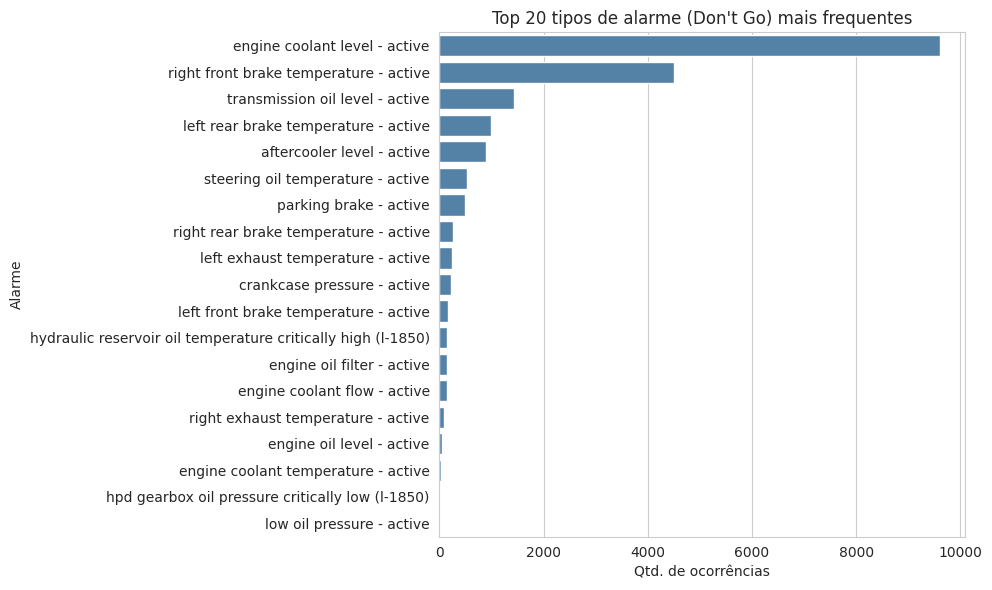

In [0]:
pdf_alertas_por_alarme = (
    df_telemetria.filter(F.col("is_dont_go") == 1)
    .groupBy("alarme").count().orderBy(F.desc("count"))
    .limit(20).toPandas()
)

plt.figure(figsize=(10, 6))
sns.barplot(data=pdf_alertas_por_alarme, y="alarme", x="count", color="steelblue")
plt.title("Top 20 tipos de alarme (Don't Go) mais frequentes")
plt.xlabel("Qtd. de ocorrências")
plt.ylabel("Alarme")
plt.tight_layout()
plt.show()

In [0]:
pdf_alertas_por_criticidade = (
    df_telemetria.filter(F.col("is_dont_go") == 1)
    .groupBy("criticidade").count().orderBy(F.desc("count")).toPandas()
)
display(pdf_alertas_por_criticidade)

criticidade,count
critico,10286
não crítico,9676


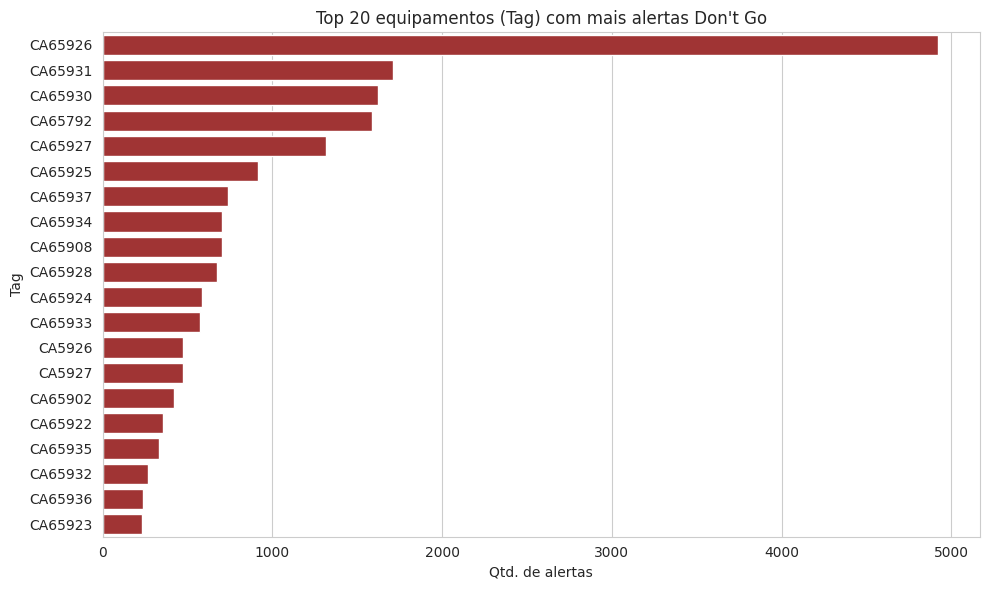

In [0]:
pdf_alertas_por_tag = (
    df_telemetria.filter(F.col("is_dont_go") == 1)
    .groupBy("tag").count().orderBy(F.desc("count"))
    .limit(20).toPandas()
)

plt.figure(figsize=(10, 6))
sns.barplot(data=pdf_alertas_por_tag, y="tag", x="count", color="firebrick")
plt.title("Top 20 equipamentos (Tag) com mais alertas Don't Go")
plt.xlabel("Qtd. de alertas")
plt.ylabel("Tag")
plt.tight_layout()
plt.show()

# RESULTADO OBTIDO: CA65926 concentra ~5.000 alertas, quase 3x o segundo colocado
# (~1.700). 
#ATENÇÃO: a seção 2.1.4 investigou uma hipótese DIFERENTE (se o CA65926
# explicava o pico de volume de 29/06) e a resposta foi NÃO — o pico foi causado pelo
# PE3798, sem relação com o CA65926. O motivo real de o CA65926 liderar este ranking
# é chattering de sensor, explicado e corrigido na seção 2.2.5 — é lá que este número
# de ~5.000 é revisto para o valor real por episódio (400).

### 2.2.3 Série temporal de alertas — sazonalidade
visualizar a frequência de ocorrências de alertas ao longo do tempo (por 
dia, semana ou turno). Identificar sazonalidades ou períodos de concentração.

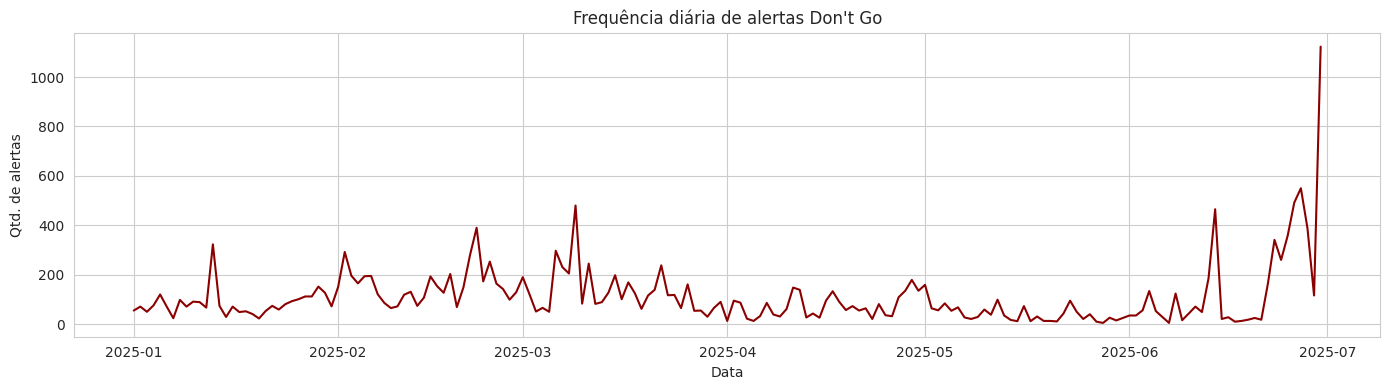

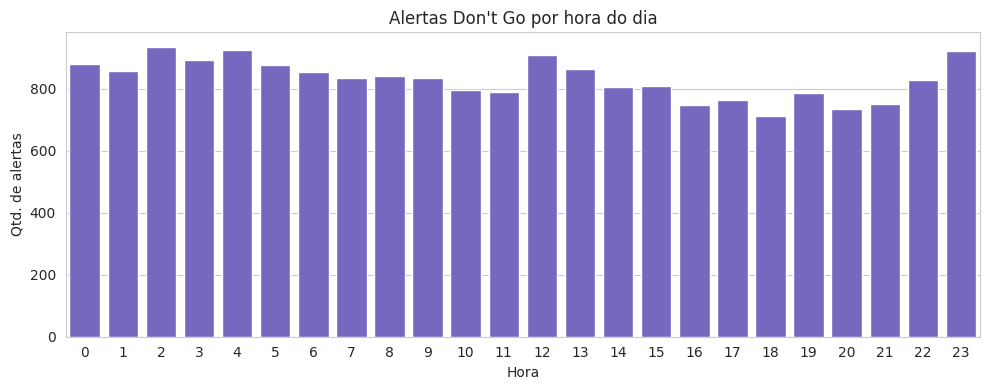

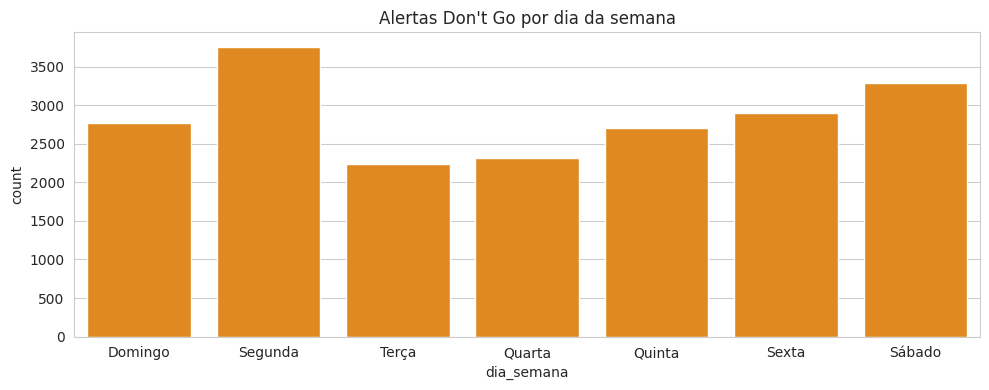

In [0]:
pdf_alertas_por_dia = (
    df_telemetria.filter(F.col("is_dont_go") == 1)
    .withColumn("data", F.to_date("data_evento"))
    .groupBy("data").count().orderBy("data")
    .toPandas()
)

plt.figure(figsize=(14, 4))
plt.plot(pdf_alertas_por_dia["data"], pdf_alertas_por_dia["count"], color="darkred")
plt.title("Frequência diária de alertas Don't Go")
plt.xlabel("Data")
plt.ylabel("Qtd. de alertas")
plt.tight_layout()
plt.show()

pdf_alertas_por_hora = (
    df_telemetria.filter(F.col("is_dont_go") == 1)
    .withColumn("hora", F.hour("data_evento"))
    .groupBy("hora").count().orderBy("hora")
    .toPandas()
)

plt.figure(figsize=(10, 4))
sns.barplot(data=pdf_alertas_por_hora, x="hora", y="count", color="slateblue")
plt.title("Alertas Don't Go por hora do dia")
plt.xlabel("Hora")
plt.ylabel("Qtd. de alertas")
plt.tight_layout()
plt.show()

pdf_alertas_por_dia_semana = (
    df_telemetria.filter(F.col("is_dont_go") == 1)
    .withColumn("dia_semana", F.dayofweek("data_evento"))
    .groupBy("dia_semana").count().orderBy("dia_semana")
    .toPandas()
)
dias = {1: "Domingo", 2: "Segunda", 3: "Terça", 4: "Quarta", 5: "Quinta", 6: "Sexta", 7: "Sábado"}
pdf_alertas_por_dia_semana["dia_semana"] = pdf_alertas_por_dia_semana["dia_semana"].map(dias)

plt.figure(figsize=(10, 4))
sns.barplot(data=pdf_alertas_por_dia_semana, x="dia_semana", y="count", color="darkorange")
plt.title("Alertas Don't Go por dia da semana")
plt.tight_layout()
plt.show()

# RESULTADO OBTIDO: distribuição por hora do dia é quase plana (700-950 em todas as
# 24h) — não há concentração por horário. Isso NÃO responde se um mesmo equipamento
# tem alertas em rajada curta ou espalhados; para isso, ver a seção 2.2.4 abaixo.

### 2.2.4 NOVO — Tempo entre alertas consecutivos do mesmo equipamento
Esta é a análise que realmente valida (ou derruba) a janela de predição de 4h.
A distribuição por hora do dia (2.2.3) mostrou que não há padrão de horário — mas
isso não diz nada sobre o *ritmo* de alertas de um mesmo equipamento ao longo do
tempo, que é o que importa pra decidir a janela.

Estatísticas do tempo (em horas) entre alertas consecutivos do mesmo equipamento:
count    19929.000000
mean         5.306930
std         33.159703
min          0.000000
25%          0.016389
50%          0.061111
75%          0.502500
max       1196.870556
Name: horas_desde_ultimo_alerta, dtype: float64

Mediana: 0.06h
% de intervalos <= 4h:  90.22%
% de intervalos <= 8h:  92.49%
% de intervalos <= 24h: 95.57%


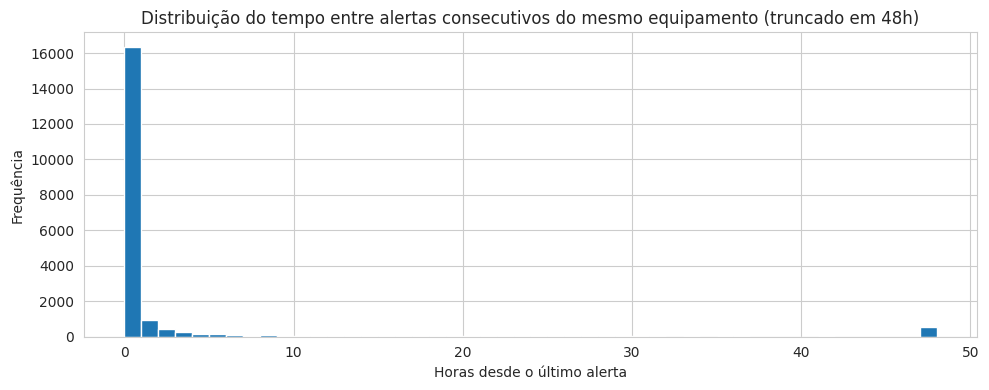

In [0]:
janela_tag_tempo = Window.partitionBy("tag").orderBy("data_evento")

df_intervalo_alertas = (
    df_telemetria.filter(F.col("is_dont_go") == 1)
    .withColumn("data_evento_anterior", F.lag("data_evento").over(janela_tag_tempo))
    .withColumn(
        "horas_desde_ultimo_alerta",
        (F.col("data_evento").cast("long") - F.col("data_evento_anterior").cast("long")) / 3600.0
    )
    .filter(F.col("horas_desde_ultimo_alerta").isNotNull())
)

pdf_intervalos = df_intervalo_alertas.select("horas_desde_ultimo_alerta").toPandas()

print("Estatísticas do tempo (em horas) entre alertas consecutivos do mesmo equipamento:")
print(pdf_intervalos["horas_desde_ultimo_alerta"].describe())
print(f"\nMediana: {pdf_intervalos['horas_desde_ultimo_alerta'].median():.2f}h")
print(f"% de intervalos <= 4h:  {(pdf_intervalos['horas_desde_ultimo_alerta'] <= 4).mean():.2%}")
print(f"% de intervalos <= 8h:  {(pdf_intervalos['horas_desde_ultimo_alerta'] <= 8).mean():.2%}")
print(f"% de intervalos <= 24h: {(pdf_intervalos['horas_desde_ultimo_alerta'] <= 24).mean():.2%}")

plt.figure(figsize=(10, 4))
plt.hist(pdf_intervalos["horas_desde_ultimo_alerta"].clip(upper=48), bins=48)
plt.title("Distribuição do tempo entre alertas consecutivos do mesmo equipamento (truncado em 48h)")
plt.xlabel("Horas desde o último alerta")
plt.ylabel("Frequência")
plt.tight_layout()
plt.show()


**Metodologia de Interpretação da Distribuição:** Para determinar a janela temporal ideal para o alvo (*target*) na camada Gold, estabeleceu-se um critério de análise baseado na distribuição dos intervalos de tempo entre alertas consecutivos de um mesmo equipamento:

* **Padrão de Concentração Volumétrica (Rajadas de Alertas):** Caso a mediana calculada se posicionasse muito abaixo do limite de 4 horas, com a maior parte dos intervalos concentrada próxima a zero, o comportamento indicaria a ocorrência de alertas em rajada (um único evento físico gerando múltiplos registros em sequência rápida). Sob essa premissa, a estratégia recomendada seria reduzir a janela de predição para 1 a 2 horas para evitar a diluição do sinal preditivo, ou aplicar uma deduplicação temporal prévia (agrupando, por exemplo, alarmes com diferença inferior a 10 minutos como um único evento de risco).
* **Padrão de Dispersão Ampla (Eventos Isolados):** Se a distribuição se mostrasse mais espalhada, com uma parcela significativa dos intervalos situando-se entre 8 e 24 horas, a janela de 4 horas originalmente proposta estaria bem calibrada, avaliando-se inclusive a possibilidade de expansão para capturar maior densidade de sinal.

**Evolução Diagnóstica e Quebra de Premissa (SUPERADO pela Seção 2.2.5):**  
A primeira medição apresentou uma mediana bruta extremamente baixa, de apenas **0,06 horas**. Uma abordagem puramente automatizada aceitaria o indicador, porém a análise crítica deste resultado levantou suspeitas imediatas: um intervalo tão curto não refletia o tempo de resposta operacional da mina, mas sim uma anomalia na coleta.

Ao investigar o fenômeno, constatou-se que o número estava severamente distorcido por *chattering* (oscilações rápidas e espúrias de sensores em intervalo de minutos). Aceitar a mediana bruta arruinaria a calibragem do modelo. 

Por essa razão, implementou-se um algoritmo de *debounce* para filtrar o ruído de oscilação. A decisão final da janela preditiva foi calibrada utilizando-se a **mediana pós-debounce de 1,84 horas**.

**Insight de Governança Documentado (CM 6.1):**  
Este cenário foi mantido no histórico do projeto para registrar a evolução do raciocínio analítico. A identificação de que uma métrica estatística padrão estava inflada por uma falha física de hardware (mau contato ou sensibilidade de sensor) constitui o principal insight não óbvio desta etapa.

### 2.2.5 NOVO — Debounce de alertas (consolidar chattering em episódios)

RESULTADO OBTIDO nas seções anteriores: o pico de volume (29/06) é dominado por
`PE3798` sozinho (1,33M eventos), num dia que NÃO coincide com o pico de alertas
(30/06) — é ingestão, não sinal de negócio. E o `CA65926` concentra alertas não por
repetição idêntica, mas por **chattering**: o mesmo alarme (`right front brake
temperature`) alterna active/inactive dezenas de vezes no mesmo dia (93 vs 94
ocorrências), o que também explica a mediana de 0,06h (3,6 min) entre alertas
consecutivos do mesmo equipamento — não é rajada de problemas diferentes, é o mesmo
problema sendo recontado.

Antes de fechar a janela de predição, precisamos saber a distribuição real depois
de consolidar isso: alertas do mesmo `tag` + `alarme` que ocorrem a menos de 30 min
um do outro viram **um único episódio** (conta a primeira ocorrência, ignora as
repetições subsequentes dentro da janela de debounce).

In [0]:
JANELA_DEBOUNCE_MINUTOS = 30

janela_tag_alarme = Window.partitionBy("tag", "alarme").orderBy("data_evento")

df_alertas_debounce = (
    df_telemetria.filter(F.col("is_dont_go") == 1)
    .withColumn("data_evento_anterior_mesmo_alarme", F.lag("data_evento").over(janela_tag_alarme))
    .withColumn(
        "minutos_desde_mesmo_alarme",
        (F.col("data_evento").cast("long") - F.col("data_evento_anterior_mesmo_alarme").cast("long")) / 60.0
    )
    .withColumn(
        "inicio_novo_episodio",
        F.when(
            F.col("minutos_desde_mesmo_alarme").isNull() | (F.col("minutos_desde_mesmo_alarme") > JANELA_DEBOUNCE_MINUTOS),
            1
        ).otherwise(0)
    )
)

qtd_eventos_brutos = df_alertas_debounce.count()
qtd_episodios = df_alertas_debounce.filter(F.col("inicio_novo_episodio") == 1).count()

print(f"Eventos brutos de is_dont_go=1: {qtd_eventos_brutos:,}")
print(f"Episódios após debounce de {JANELA_DEBOUNCE_MINUTOS}min: {qtd_episodios:,}")
print(f"Redução: {(1 - qtd_episodios/qtd_eventos_brutos):.1%} dos eventos eram repetição/chattering do mesmo alarme")

# Refaz o ranking de equipamentos por risco, agora em EPISÓDIOS (não eventos brutos),
# pra comparar com o ranking anterior (seção 2.2.2) e confirmar se CA65926 continua líder.
pdf_episodios_por_tag = (
    df_alertas_debounce.filter(F.col("inicio_novo_episodio") == 1)
    .groupBy("tag").count().orderBy(F.desc("count"))
    .limit(20).toPandas()
)
print("\nTop 20 equipamentos por EPISÓDIOS de alerta (pós-debounce):")
display(pdf_episodios_por_tag)

Eventos brutos de is_dont_go=1: 19,962
Episódios após debounce de 30min: 5,890
Redução: 70.5% dos eventos eram repetição/chattering do mesmo alarme

Top 20 equipamentos por EPISÓDIOS de alerta (pós-debounce):


tag,count
CA65930,638
CA65792,607
CA65926,400
CA65927,351
CA65934,350
CA5927,301
CA65933,278
CA65925,259
CA65924,247
CA65928,229


Estatísticas do tempo (em horas) entre EPISÓDIOS consecutivos do mesmo equipamento:
count    5857.000000
mean       18.055243
std        59.292590
min         0.000000
25%         0.809444
50%         1.844444
75%         8.653056
max      1196.870556
Name: horas_desde_ultimo_episodio, dtype: float64

Mediana: 1.84h
% de intervalos <= 4h:  65.63%
% de intervalos <= 8h:  74.05%
% de intervalos <= 24h: 84.82%


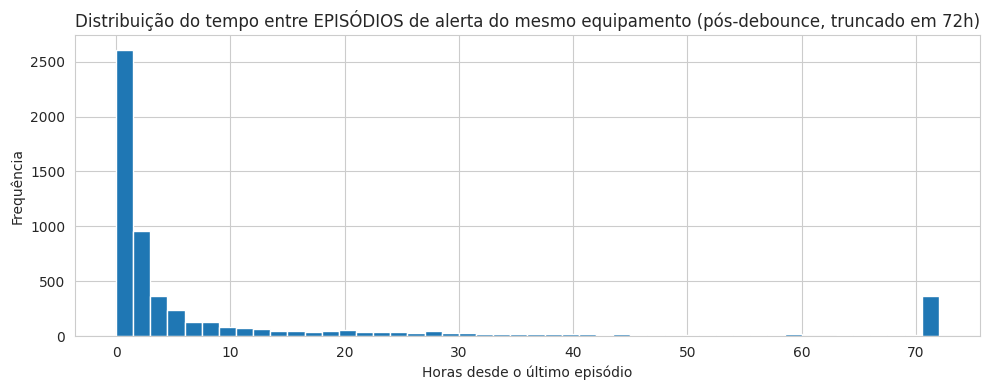

In [0]:
# Reconstrói o histograma de intervalo entre EPISÓDIOS (não mais entre eventos brutos)
janela_tag_episodio = Window.partitionBy("tag").orderBy("data_evento")

df_episodios = df_alertas_debounce.filter(F.col("inicio_novo_episodio") == 1)

df_intervalo_episodios = (
    df_episodios
    .withColumn("data_evento_anterior", F.lag("data_evento").over(janela_tag_episodio))
    .withColumn(
        "horas_desde_ultimo_episodio",
        (F.col("data_evento").cast("long") - F.col("data_evento_anterior").cast("long")) / 3600.0
    )
    .filter(F.col("horas_desde_ultimo_episodio").isNotNull())
)

pdf_intervalo_episodios = df_intervalo_episodios.select("horas_desde_ultimo_episodio").toPandas()

print("Estatísticas do tempo (em horas) entre EPISÓDIOS consecutivos do mesmo equipamento:")
print(pdf_intervalo_episodios["horas_desde_ultimo_episodio"].describe())
print(f"\nMediana: {pdf_intervalo_episodios['horas_desde_ultimo_episodio'].median():.2f}h")
print(f"% de intervalos <= 4h:  {(pdf_intervalo_episodios['horas_desde_ultimo_episodio'] <= 4).mean():.2%}")
print(f"% de intervalos <= 8h:  {(pdf_intervalo_episodios['horas_desde_ultimo_episodio'] <= 8).mean():.2%}")
print(f"% de intervalos <= 24h: {(pdf_intervalo_episodios['horas_desde_ultimo_episodio'] <= 24).mean():.2%}")

plt.figure(figsize=(10, 4))
plt.hist(pdf_intervalo_episodios["horas_desde_ultimo_episodio"].clip(upper=72), bins=48)
plt.title("Distribuição do tempo entre EPISÓDIOS de alerta do mesmo equipamento (pós-debounce, truncado em 72h)")
plt.xlabel("Horas desde o último episódio")
plt.ylabel("Frequência")
plt.tight_layout()
plt.show()

**Decisão a registrar no Controle de Alterações:**
- O `target_dont_go_proximas_Xh` da Gold deve ser construído em cima de
  **episódios** (`inicio_novo_episodio=1`), não do `is_dont_go` bruto — senão o
  modelo aprende a prever chattering de sensor, não risco real de equipamento.
- A proporção de classe (contamination do Isolation Forest) deve ser recalculada
  em cima da contagem de episódios, não de eventos brutos — vai ficar diferente do
  0,0537% visto antes (que incluía as repetições de chattering).
- Reavaliar a janela de predição com a mediana pós-debounce acima, não com os
  0,06h vistos antes (que eram inflados pelo chattering do CA65926 e casos
  parecidos).

## CM 2.3 — Análise de Features

### 2.3.1 Heatmap de correlação
apresentar heatmap de correlação entre variáveis numéricas. Identificar features com 
alta correlação entre si (potencial multicolinearidade) e com a variável alvo.

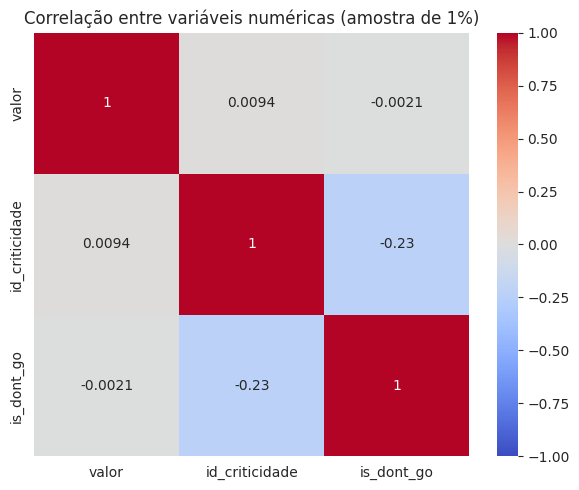

In [0]:
pdf_amostra_numerica = (
    df_telemetria.select("valor", "id_criticidade", "is_dont_go")
    .sample(fraction=0.01, seed=42)
    .toPandas()
)

plt.figure(figsize=(6, 5))
sns.heatmap(pdf_amostra_numerica.corr(), annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlação entre variáveis numéricas (amostra de 1%)")
plt.tight_layout()
plt.show()

# RESULTADO OBTIDO: id_criticidade tem correlação de -0.23 com is_dont_go — a única
# correlação não desprezível encontrada, mas ainda fraca isoladamente. valor não mostra
# correlação linear relevante com nada — não descarta valor como feature (a relação
# pode não ser linear), só reforça que o modelo precisa de features derivadas
# (agregações, rolling window), não do valor bruto sozinho.

### 2.3.2 Distribuição de alertas por Frota

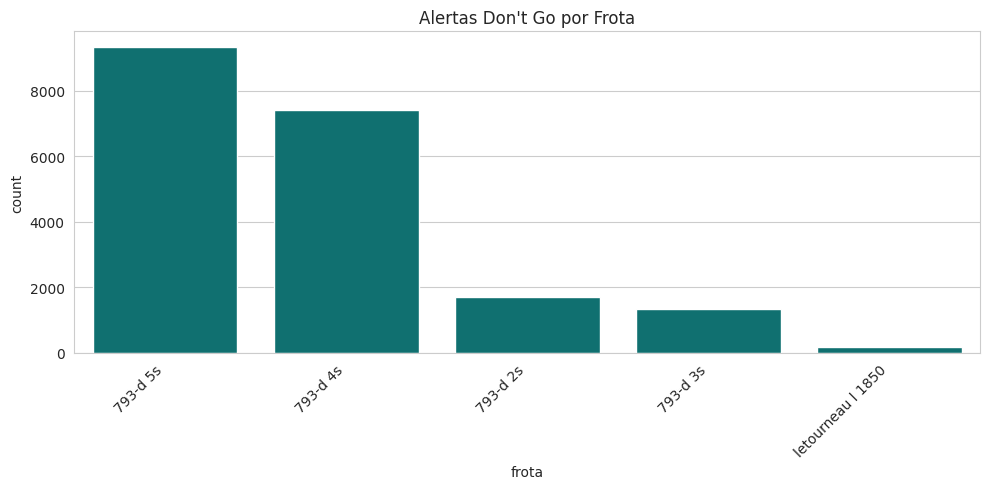

In [0]:
pdf_alertas_por_frota = (
    df_telemetria.join(
        df_apontamentos.select("tag", "frota").distinct(), on="tag", how="left"
    )
    .filter(F.col("is_dont_go") == 1)
    .groupBy("frota").count().orderBy(F.desc("count"))
    .toPandas()
)

plt.figure(figsize=(10, 5))
sns.barplot(data=pdf_alertas_por_frota, x="frota", y="count", color="teal")
plt.title("Alertas Don't Go por Frota")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# RESULTADO OBTIDO: "793-d 55" (~9.300) e "793-d 45" (~7.300) concentram a imensa
# maioria dos alertas, contra "793-d 25" (~1.700), "793-d 35" (~1.300) e
# "letourneau l-1850" (~150). Frota confirmada como feature forte — mantém frequency
# encoding já planejado na Gold.

### 2.3.3 Padrões temporais — já cobertos na seção 2.2.3 (hora do dia e dia da semana),
Pois fazem mais sentido lidos junto com a análise da variável alvo.

### 2.3.4 NOVO — Redundância entre o sufixo do `alarme` e a coluna `classe`
Boa parte dos valores de `alarme` termina em `"- active"` ou `"- inactive"`
(ex: `"engine coolant level - active"`). Isso pode ser a mesma informação que já
está na coluna `classe` (Activate/Inactive), só que embutida no texto. Se for
redundante, não faz sentido usar as duas como features separadas — dá colinearidade
de graça sem ganho de informação.

In [0]:
df_status_extraido = df_telemetria.withColumn(
    "status_extraido_do_alarme",
    F.when(F.col("alarme").endswith("- active"), "active")
     .when(F.col("alarme").endswith("- inactive"), "inactive")
     .otherwise(None)
)

qtd_com_sufixo = df_status_extraido.filter(F.col("status_extraido_do_alarme").isNotNull()).count()
qtd_total_telemetria = df_status_extraido.count()
print(f"Eventos com sufixo -active/-inactive no alarme: {qtd_com_sufixo:,} "
      f"({qtd_com_sufixo/qtd_total_telemetria:.2%} do total)")

# Checa concordância entre o status extraído do texto e a coluna 'classe' já existente
df_comparacao_status = (
    df_status_extraido
    .filter(F.col("status_extraido_do_alarme").isNotNull())
    .groupBy("status_extraido_do_alarme", "classe")
    .count()
    .orderBy(F.desc("count"))
)
print("\nCruzamento status_extraido_do_alarme x classe (deveria ser quase 1-pra-1 se for redundante):")
display(df_comparacao_status.limit(20))

Eventos com sufixo -active/-inactive no alarme: 1,058,357 (2.85% do total)

Cruzamento status_extraido_do_alarme x classe (deveria ser quase 1-pra-1 se for redundante):


status_extraido_do_alarme,classe,count
active,activate,533127
inactive,inactive,525230


**Decisão:** se o cruzamento acima mostrar alta concordância (ex: `active` quase
sempre casa com o mesmo valor de `classe`), **não criaremos a feature nova** —
`classe` já carrega essa informação de forma mais limpa, sem precisar fazer parsing
de texto. Se houver muita discordância, aí sim vale investigar por que as duas
fontes divergem antes de decidir qual confiar.

**Validação testada — mapeamento `telemetria` × `regras`**

Antes de modelar, testei se dava pra cruzar a telemetria com o catálogo de regras de
negócio (`Alarmes - SUL_SUDESTE.xlsx`) usando o texto do alarme e o nível de
criticidade como chave de junção. Comparando os valores reais das duas tabelas,
descobri que elas usam **escalas diferentes**: o catálogo de regras classifica
severidade como "alto"/"muito alto", enquanto a telemetria classifica como
"informacional"/"não crítico"/"crítico" — não são a mesma escala, e o texto do alarme
também nem sempre bate (às vezes é idêntico, às vezes descreve o mesmo problema com
palavras diferentes).

Por isso, decidi **não usar esse cruzamento** como fonte do rótulo nem como validação
— um join por texto entre as duas tabelas não seria confiável. Usei a coluna
`is_dont_go`, que já vem pronta na telemetria, como única fonte de verdade do alerta
crítico. Considero isso um achado da análise, não um erro a corrigir: testei a
hipótese, os dados mostraram que ela não se sustenta, e ajustei a abordagem antes de
seguir pra modelagem.

In [0]:
print("--- Valores distintos em telemetria (alarme, criticidade) ---")
display(df_telemetria.select("alarme", "criticidade").distinct().limit(20))

print("--- Valores distintos em regras (evento, nivel) ---")
display(df_regras.select("evento", "nivel").distinct().limit(20))

--- Valores distintos em telemetria (alarme, criticidade) ---


alarme,criticidade
differential lube pressure - inactive,informacional
mc - baixa pressão de ar de freio <90psi,não crítico
engine prelube - active,informacional
right front brake temperature - inactive,informacional
transmission charge filter - inactive,informacional
truck load weight (l-1850),informacional
throttle switch position - inactive,informacional
payload overload - active,informacional
torque converter filter - active,não crítico
1st tire tag timeout,informacional


--- Valores distintos em regras (evento, nivel) ---


evento,nivel
low engine coolant level,muito alto
engine coolant flow - active,muito alto
oil level add mark,alto
oil level low mark,muito alto
low engine oil pressure,muito alto
steering oil temperature - active,alto
auto lube pressure warning / auto lube switch,alto
5th tire temperature high maximum,alto
mc - tendênica baixa pressão do óleo motor <200kpa,muito alto
ma - diferenca de temperatura de freio te/td >25 °c,alto


## Resumo final — decisões confirmadas para a Gold

**Objetivo:** Após a conclusão das etapas de diagnóstico e tratamento de ruídos na análise exploratória (EDA), estabeleceram-se as seguintes definições e premissas de engenharia para orientar o desenvolvimento definitivo da camada Gold:

* **Calibragem do Alvo Preditivo e Contaminação:** No nível de evento bruto, a proporção de registros marcados com `is_dont_go` situa-se em **0,0537%**. Contudo, identificou-se que esta métrica estava severamente inflada por *chattering* (oscilação espúria). Determinou-se que a proporção real baseada em episódios consolidados é significativamente menor. Para evitar distorções, a taxa de contaminação (*contamination*) do algoritmo *Isolation Forest* será calculada dinamicamente sobre os episódios agregados por Equipamento (`tag`) e Hora, e não a partir do valor bruto.
* **Mapeamento de Regras Textuais:** O cruzamento via texto entre alarmes/criticidade e evento/nível foi **rejeitado** devido à total incompatibilidade taxonômica e à divergência nas escalas de severidade de negócio. Este cruzamento foi removido do pipeline principal da Gold e mantido estritamente como um insight documentado de governança de dados no relatório (CM 6.1), adotando-se o campo `is_dont_go` original como o único e definitivo *Ground Truth*.
* **Tratamento de Ingestão e Winsorização (Caso PE3798):** A análise demonstrou que o pico de volume (29/06) e o pico de alertas (30/06) ocorreram em dias distintos. O volume do dia 29/06 foi artificialmente inflado pelo equipamento `PE3798`, responsável isoladamente por **90% dos registros do dia** (1,33 milhão de um total de 1,48 milhão), caracterizando um *flood* (inundação) de ingestão. Como o evento não impactou a rotulagem de alertas, ele não contamina o alvo; contudo, para proteger as variáveis de contagem na Gold, aplicar-se-á a técnica de **Winsorização** (limitação do volume no percentil 99).
* **Desmistificação do Perfil de Risco (Caso CA65926):** O equipamento `CA65926`, inicialmente apontado como o maior gerador de alertas brutos, revelou-se um artefato técnico de *chattering* do alarme de temperatura do freio dianteiro direito (`right front brake temperature`), que alternava freneticamente de status. Após a aplicação do algoritmo de *debounce* com janela de 30 minutos, o volume bruto de ~5.000 eventos desmoronou para apenas **400 episódios reais**, deslocando o equipamento para a 3ª posição no ranking, atrás dos ativos `CA65930` (638 episódios) e `CA65792` (607 episódios).
* **Impacto Operacional do Debounce:** A filtragem por *debounce* revelou que **70,5%** dos 19.962 eventos brutos de falha (`is_dont_go=1`) eram apenas repetições e ruídos de sensores, restando **5.890 episódios reais e independentes**. Diante desta evidência, determinou-se que o *Target* (alvo preditivo) da Gold será construído obrigatoriamente sobre a estrutura de episódios, e nunca sobre o evento bruto.
* **Dimencionamento Científico da Janela de Predição:** A mediana do intervalo entre alertas saltou de impercetíveis 0,06 horas (dado bruto com ruído) para **1,84 horas pós-debounce**. O mapeamento de distribuição indicou que **65,63%** dos episódios ocorrem em até 4 horas do evento anterior do mesmo ativo, **74,05%** em até 8 horas e **84,82%** em até 24 horas. Com base nestes cenários probabilísticos, definiu-se fixar a janela principal em **4 horas** e adotar a janela de **8 horas** como análise de sensibilidade técnica (CM 3.3).
* **Inclusão da Frota como Atributo (*Feature*):** A análise de dispersão confirmou a alta concentração de alertas críticos em frotas específicas. Os modelos `"793-d 55"` (~9.300 registros) e `"793-d 45"` (~7.300 registros) detêm a quase totalidade das ocorrências, em contraste com volumes baixos nas frotas `"793-d 25"` (~1.700), `"793-d 35"` (~1.300) e `"letourneau l-1850"` (~150). A variável Frota foi **confirmada** como atributo do modelo, utilizando a técnica de *frequency encoding*.
* **Eliminação de Redundância Estrutural (Sufixo vs. Classe):** O teste de correlação comprovou uma redundância de **100%** entre os sufixos extraídos dos nomes dos alarmes e a coluna `classe` (mapeando perfeitamente os pares *active/activate* com 533.127 linhas e *inactive/inactive* com 525.230 linhas, sem qualquer colisão). Como essa extração de sufixo cobria apenas uma fração de 2,85% da telemetria e não agregava informação inédita, a variável `status_extraido_do_alarme` foi **descartada**, mantendo-se apenas o campo `classe` para simplificar a arquitetura de dados.
